In [101]:
print("test")

test


In [102]:
#Charger dataset
from datasets import load_dataset
import numpy as np

In [103]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [104]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [105]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [106]:
# train_df.head()
train_df.sample(5)

,text,label
11725,This move reminded my of Tales from the Crypt ...,0
15736,"A great film this, and a shame that it will re...",1
1764,This movie is really nothing besides an admitt...,0
10510,OK I saw this movie to get a benchmark for bad...,0
19192,"'Where the Sidewalk Ends (1950)' opens, approp...",1


In [107]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [108]:
# train_df['sentiment'] = train_df['label'].map({0: 'negative', 1: 'positive'})
train_df['sentiment'] = np.where(train_df['label']==1, "positive","negative")

In [109]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [110]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

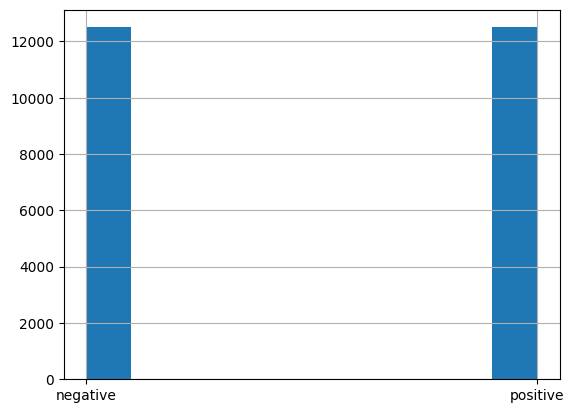

In [111]:
train_df.sentiment.hist()

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [114]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [115]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 

In [116]:
import json

In [117]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

## Elaborer les prompts

#### Prompt 1: Zero-shot

In [118]:
user_prompt_template = """```{movie_review}```"""

In [119]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [120]:
zero_shot_prompt = [
    {"role":"system", "content": zero_shot_system_message}
]

In [121]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [122]:
#pour le few shot prompt nous aurons besoin de quelques exemples variés, cad des critiques positives et négatives
#on va diviser les examples on deux (positive et negative) et prendre 4 exemples de chaque pour les inclure in random order dans le prompt few shot
examples_df.shape

(20000, 3)

In [ ]:
positive_reviews_df = (
        examples_df[examples_df.sentiment=="positive"][columns]
        .sample(4)
)

In [124]:
negative_reviews_df = (
                examples_df[examples_df.sentiment=="negative"][columns]
                .sample(4))

In [125]:
negative_reviews_df

,text,sentiment
11483,OH MY GOD.. THE WORST SH*T I'VE EVER SEEN -thi...,negative
4201,"While channel surfing, we found this movie wit...",negative
4423,"A reporter, Craig Milford, who works for The J...",negative
4465,"Way back when, the X-Files was an intelligent,...",negative


In [126]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [127]:
import pandas as pd

In [128]:
ex = pd.concat([positive_reviews_df, negative_reviews_df])

In [129]:
ex
#problème : les exemples positifs sont regroupés et les négatifs aussi, il faut les mélanger

,text,sentiment
20735,"Now this is what I'm talking about. Finally, a...",positive
19107,Comedies often have the unfortunate reputation...,positive
17395,This movie is a little ray of sunshine in a da...,positive
20847,"1927, and Hollywood had been on the map as the...",positive
11483,OH MY GOD.. THE WORST SH*T I'VE EVER SEEN -thi...,negative
4201,"While channel surfing, we found this movie wit...",negative
4423,"A reporter, Craig Milford, who works for The J...",negative
4465,"Way back when, the X-Files was an intelligent,...",negative


In [130]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [131]:
json.loads(examples)

[{'text': '"Metamorphosis" hold a tiny bit of cult-value, simply because it was written and directed by George Eastman. This Italian bloke is more or less the personification of male sleaze and starred in pretty much every rancid Joe D\'Amato production during the late 70\'s/early 80\'s. Wouldn\'t it be interesting for avid Euro-cult purchasers to own the only movie directed by the guy who walked around bare-butted in "Erotic Nights of the Living Dead" all the time? I thought so! Now, unlike the movies he starred in, Eastman\'s own "Metamorphosis" is kind of disappointing in the gore & sleaze departments. There are a handful of nasty murders, cheesy monster effects and naked female bodies (a guest appearance by sleaze-queen Laura Gemser!) on display, but it\'s mainly a talkative movie. The handsome & eloquent Dr. Houseman is on the verge of a scientific breakthrough with his research on human DNA codes when suddenly the university he works for threatens to cancel his funds. He develope

In [132]:
def create_examples(dataset, n=4):
    positive_reviews_df = (
                dataset[dataset['sentiment'] == 'positive'][columns]
                .sample(n)
                )
    negative_reviews_df = (
                dataset[dataset['sentiment'] == 'negative'][columns]
                .sample(n)
                )

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(2*n, replace=False)
    
    return examples.to_json(orient='records')

In [133]:
examples_df.shape

(20000, 3)

In [134]:
few_shot_examples = create_examples(examples_df, n=1)

In [135]:
json.loads(few_shot_examples)

[{'text': 'This was a watershed event in my movie watching life. I went to see this in the theater when it came out. I was completely amazed at just how bad it was. Movies like this make you wonder who put the money up and who owed whom a favor - a very, very large favor. The special effects are absolutely first grade level, as in any first grader could have done them. Toy rubber bats on strings with no attempt to hide the strings, arrows that appear to be drawn on the film and look to be the shape of an arrow you\'d find on a street sign, and a laughable story line. Ed Wood made masterpieces compared to "Conquest". Every film student should see this thing just so they\'ll know the very definition of a bad movie.',
  'sentiment': 'negative'},
 {'text': "In my opinion, this is an absolutely romantic Disney masterpiece. If you ask me, the stepmother (voice of Lucille La Verne) was truly diabolical. You'll have to see the movie if you want to know why. On the other hand, despite the fact 

In [136]:
#few shot propt fct:
def create_few_shot_prompt(system_message, examples, user_prompt_template):
    few_shot_prompt = [
        {"role": "system", "content": system_message},
    ]

    for example in json.loads(examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        few_shot_prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        few_shot_prompt.append({"role": "assistant", "content": f"{sentiment}"}) 
        #la format f"{}" c'est juste pour spécifier que c est du text

    return few_shot_prompt

In [137]:
few_shot_prompt = create_few_shot_prompt(few_shot_system_message, few_shot_examples, user_prompt_template)

In [138]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```This was a watershed event in my movie watching life. I went to see this in the theater when it came out. I was completely amazed at just how bad it was. Movies like this make you wonder who put the money up and who owed whom a favor - a very, very large favor. The special effects are absolutely first grade level, as in any first grader could have done them. Toy rubber bats on strings with no attempt to hide the strings, arrows that appear to be drawn on the film and look to be the shape of an arrow you\'d find on a street sign, and a laughable story line. Ed Wood made masterpieces compared to "Conquest". Every film student should see this thing just so they\'ll know the very definition

## Chain of thought

In [139]:
#cot: chain of thought prompting, c'est une technique qui consiste à demander au modèle de raisonner étape par étape pour arriver à la réponse finale(instructions a suivre)
cot_few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.

Instructions:
1.Carefully read the text of the review and think through the options for sentiment provided. 
2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative

To reiterate, your answer should strictly only contain the labels: positive or negative.
"""

In [140]:
cot_few_shot_prompt = create_few_shot_prompt(
                        cot_few_shot_system_message, 
                        few_shot_examples, 
                        user_prompt_template
                        )

In [141]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n\nInstructions:\n1.Carefully read the text of the review and think through the options for sentiment provided. \n2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative\n\nTo reiterate, your answer should strictly only contain the labels: positive or negative.\n"},
 {'role': 'user',
  'content': '```This was a watershed event in my movie watching life. I went to see this in the theater when it came out. I was completely amazed at just how bad it was. Movies like this make you wonder who put the money up and who owed whom a favor - a very, very large favor. The special effects are absolutely first grade level, as in any first grader could have done them. Toy rubber 

## Evaluation des trois prompts avec ollama

In [142]:
from sklearn.metrics import f1_score

In [ ]:
#fct d'évalutions des prompt:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm='llama3.2'):
    predicted_sentiments = []
    ground_truth_sentiments=[]

    for example in json.loads(gold_examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        user_input = {"role":"user", "content": user_prompt_template.format(movie_review=review)} 

        try:
            resp = llm.invoke(prompt + [user_input])
            if 'negative' in resp.content.strip().lower():
                predicted = 'negative'

            elif 'positive' in resp.content.strip().lower():
                predicted = 'positive'

            else:
                predicted = 'unknown'

            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)

            #print(predicted, sentiment)

        except Exception as e:
            print(f"Error processing review: {e}")
            predicted = 'error'
            continue
    return f1_score(ground_truth_sentiments, predicted_sentiments, average='micro')


In [144]:
#Pour évaluer un prompt il faut d'abord définir les mesures d'évaluation, 
#Les plus courantes sont la précision, le rappel et le F1-score, accuracy(trop simple). 

#on utilisera:
#score micro-F1 = 2 * (precision * recall) / (precision + recall)


In [145]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2", temperature=0)
#run the command in cmd: ollama run llama3.2

In [146]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.9

In [147]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.9

In [148]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
negative positive
positive positive
negative negative


0.85

In [ ]:
#now we will 
from tqdm import tqdm

num_eval_runs = 10
performances = []

for _ in tqdm(range(num_eval_runs)):
    examples = create_examples(examples_df, n=4)
    fsp = create_few_shot_prompt(few_shot_system_message, examples, user_prompt_template)
    score = evaluate_prompt(fsp, gold_examples, user_prompt_template, llm)
    performances.append(score)
mean = np.array(performances).mean()
std = np.array(performances).std()
print(f"Mean: {mean}, Std: {std}")